Processing images...
Loading class: Bus → Large (Bus/Truck)
Loading class: Microbus → Medium (SUV/Microbus)
Loading class: Minivan → Small (Sedan/Minivan)
Loading class: Sedan → Small (Sedan/Minivan)
Loading class: SUV → Medium (SUV/Microbus)
Loading class: Truck → Large (Bus/Truck)

Total samples: 1995
Feature vector length: 24300
Samples per merged class: Counter({np.str_('Small (Sedan/Minivan)'): 1206, np.str_('Medium (SUV/Microbus)'): 573, np.str_('Large (Bus/Truck)'): 216})
Merged classes: ['Large (Bus/Truck)' 'Medium (SUV/Microbus)' 'Small (Sedan/Minivan)']

Using 5-fold Stratified Cross‑Validation
CV scores: [0.73182957 0.78446115 0.75438596 0.79699248 0.73934837]
Mean CV accuracy: 0.7614035087719299
Std Dev: 0.025331887255124363

Cross‑Validated Classification Report:
                       precision    recall  f1-score   support

    Large (Bus/Truck)       0.81      0.61      0.69       216
Medium (SUV/Microbus)       0.59      0.58      0.59       573
Small (Sedan/Minivan)  

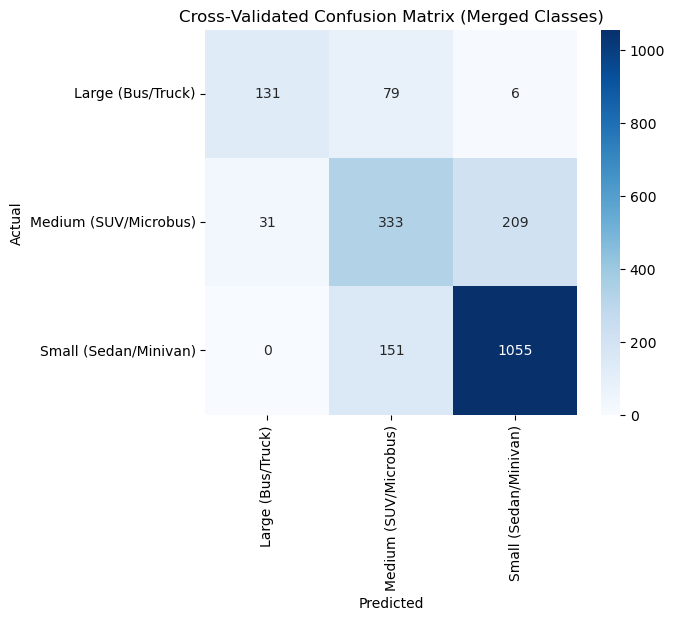


Training final model...

Final Test Classification Report:
                       precision    recall  f1-score   support

    Large (Bus/Truck)       0.81      0.58      0.68        43
Medium (SUV/Microbus)       0.58      0.58      0.58       115
Small (Sedan/Minivan)       0.82      0.86      0.84       241

             accuracy                           0.75       399
            macro avg       0.74      0.68      0.70       399
         weighted avg       0.75      0.75      0.75       399



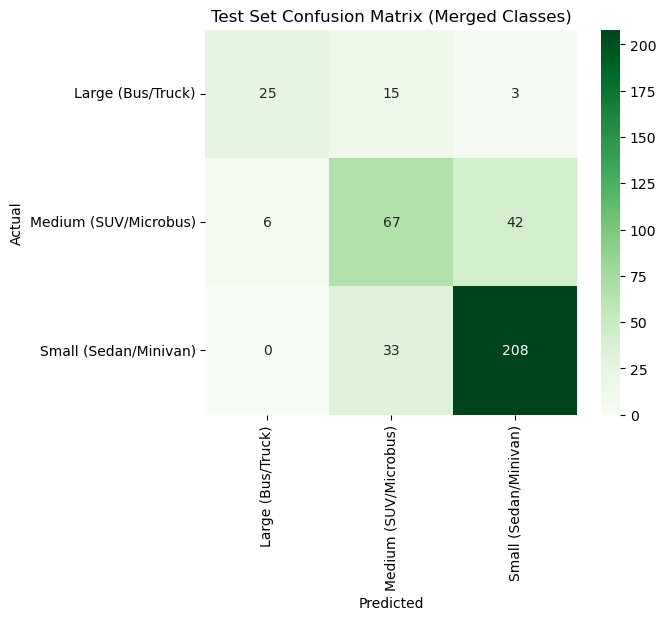


Model and encoder saved.


In [ ]:
import os
import cv2
import numpy as np
from collections import Counter

from skimage.feature import hog
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


# Set configuration and image folder path
IMAGE_FOLDER = "C:/Users/clair/Downloads/CARLA"
IMG_SIZE = (128, 128)
TEST_SIZE = 0.2
RANDOM_STATE = 42


# Merge classes together
CLASS_MAP = {
    "Sedan": "Small (Sedan/Minivan)",
    "Minivan": "Small (Sedan/Minivan)",

    "SUV": "Medium (SUV/Microbus)",
    "Microbus": "Medium (SUV/Microbus)",

    "Bus": "Large (Bus/Truck)",
    "Truck": "Large (Bus/Truck)"
}


# Load images from dataset
def load_dataset(root):
    features = []
    labels = []

    print("Processing images...")

    for class_name in os.listdir(root):
        class_path = os.path.join(root, class_name)

        if not os.path.isdir(class_path):
            continue

        # Map original class to merged class
        merged_label = CLASS_MAP.get(class_name)
        if merged_label is None:
            continue

        print(f"Loading class: {class_name} → {merged_label}")

        for img_name in os.listdir(class_path):
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, IMG_SIZE)

            # Extract color HOG features
            hog_features = []

            for channel in range(3):
                channel_features = hog(
                    img[:, :, channel],
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm="L2-Hys"
                )
                hog_features.extend(channel_features)

            features.append(hog_features)
            labels.append(merged_label)

    return np.array(features), np.array(labels)



def main():
    X, labels = load_dataset(IMAGE_FOLDER)

    print("\nTotal samples:", len(labels))
    print("Feature vector length:", X.shape[1])

    # Show merged class balance
    counts = Counter(labels)
    print("Samples per merged class:", counts)

    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(labels)

    print("Merged classes:", le.classes_)

    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True
        ))
    ])

    # Cross validation
    min_samples = min(counts.values())
    n_splits = min(5, min_samples)

    print(f"\nUsing {n_splits}-fold Stratified Cross‑Validation")

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    cv_scores = cross_val_score(pipeline, X, y, cv=skf)

    print("CV scores:", cv_scores)
    print("Mean CV accuracy:", cv_scores.mean())
    print("Std Dev:", cv_scores.std())

    y_pred_cv = cross_val_predict(pipeline, X, y, cv=skf)

    print("\nCross‑Validated Classification Report:")
    print(classification_report(y, y_pred_cv, target_names=le.classes_))

    cm_cv = confusion_matrix(y, y_pred_cv)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_cv, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap="Blues")
    plt.title("Cross‑Validated Confusion Matrix (Merged Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # -Train and test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    print("\nTraining final model...")
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print("\nFinal Test Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap="Greens")
    plt.title("Test Set Confusion Matrix (Merged Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    import joblib

    MODEL_PATH = "C:/Users/clair/Senior-Project/models/vehicle_svm_pipeline1.pkl"
    ENCODER_PATH = "C:/Users/clair/Senior-Project/models/vehicle_label_encoder1.pkl"

    joblib.dump(pipeline, MODEL_PATH)
    joblib.dump(le, ENCODER_PATH)

    print("\nModel and encoder saved.")



if __name__ == "__main__":
    main()